In [81]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F

# Gráficos vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [82]:
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [83]:
# Hiperparámetros para GPT2-124M
n_vocab    = 50257     # Tamaño del vocabulario de GPT-2
embed_dim  =   768     # Dimensión del embedding
seq_len    =   256     # Longitud máxima de secuencia
n_heads    =    12     # Cabezas de atención
n_blocks   =    12     # Bloques de transformer
batch_size =    16

# Usar GPU si está disponible
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Cambiando datos por otro libro

In [84]:
# Tokenizar el texto
# Los viajes de Gulliver :)
text = requests.get('https://www.gutenberg.org/cache/epub/829/pg829.txt').text
gtTokens = torch.tensor(tokenizer.encode(text))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (158340 > 1024). Running this sequence through the model will result in indexing errors


In [85]:
# División en entrenamiento/prueba
train_ratio = 0.9

# Índice para dividir los datos
test_split_point = int(train_ratio * len(gtTokens))

train_data = gtTokens[:test_split_point]
test_data  = gtTokens[test_split_point:]

In [86]:
# Una función que retorna un lote de muestras de datos
def get_data_batch(training=True):

  # Elegir el conjunto de datos a usar
  if training:
    data = train_data
  else:
    data = test_data

  # Elegir índices aleatorios de inicio
  ix = torch.randint(len(data) - seq_len, size=(batch_size,))

  # Obtener los datos y objetivos (vía broadcasting / producto exterior)
  X = data[ix[:, None] + torch.arange(seq_len)]
  y = data[ix[:, None] + torch.arange(1, seq_len + 1)]
  return X, y

In [87]:
# Ejemplo (cada vez que corra el codigo el size siempre sera el mismo lotes por ventana de contexto)
X, y = get_data_batch()
print(f'Datos de entrada (tamaño {X.shape}):\n', X)
print(f'\n\nObjetivos (tamaño {y.shape}):\n', y)

Datos de entrada (tamaño torch.Size([16, 256])):
 tensor([[   82,    62,   547,  ..., 12428,   495,   286],
        [12399,  3450,    13,  ...,   739,   884,  5917],
        [17989,  2627, 28881,  ...,   250,  2061, 10848],
        ...,
        [   11, 16568,    11,  ...,   661,  4855,  2405],
        [  616,   201,   198,  ...,   361,   616, 10251],
        [13617,   373,  3338,  ...,   389,  1913,   290]])


Objetivos (tamaño torch.Size([16, 256])):
 tensor([[   62,   547,  9393,  ...,   495,   286,  1719],
        [ 3450,    13,   314,  ...,   884,  5917,    13],
        [ 2627, 28881,    30,  ...,  2061, 10848,   547],
        ...,
        [16568,    11, 21608,  ...,  4855,  2405,   416],
        [  201,   198, 13948,  ...,   616, 10251,   550],
        [  373,  3338,   357,  ...,  1913,   290,  1327]])


In [88]:
class MultiHeadAttention(nn.Module):
  def __init__(self):
    super().__init__()

    # Número de cabezales de atención
    self.num_heads = n_heads
    self.head_dim  = embed_dim // n_heads

    # Las tres matrices de pesos Q, K, V se inicializan como una sola y se dividen dentro de forward()
    self.QKV = nn.Linear(embed_dim, 3*embed_dim, bias=True)

    # Mezcla lineal posterior a la atención
    self.W0 = nn.Linear(embed_dim, embed_dim, bias=True)


  def forward(self, x):

    # Dimensiones para usar más adelante
    B, T, E = x.shape # [batch, long_secuencia, dim_embedding]

    # Pasar los datos a través de Q, K y V en una sola matriz concatenada
    qkv = self.QKV(x) # [batch, secuencia, 3*dim_embedding]
    q, k, v = torch.split(qkv, E, dim=2) # Cada matriz es [B, T, E]

    # Redimensionar a [B, T, nHeads, head_dim]
    #  y luego transponer a [B, nHeads, T, head_dim]
    q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2) # [B, nHeads, T, head_dim]
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    # La función de atención por producto punto escalado de PyTorch maneja dimensiones multicabezal
    out = F.scaled_dot_product_attention(q, k, v, is_causal=True) # [B, nHeads, T, head_dim]

    # Recombinar cabezales: (B, nHeads, T, head_dim) -> [B, T, E]
    out = out.transpose(1, 2).view(B, T, E)

    # Finalmente, proyectar linealmente los cabezales de atención
    out = self.W0(out)

    return out

In [89]:
class TransformerBlock(nn.Module):
  def __init__(self):
    super().__init__()

    ### Subbloque de atención
    self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
    self.attn = MultiHeadAttention()

    ### Subbloque feedforward lineal (MLP)
    self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
    # Expansión 4x, luego de regreso al tamaño de embedding
    self.mlp_1 = nn.Linear(embed_dim, 4*embed_dim, bias=True)
    self.gelu  = nn.GELU()
    self.mlp_2 = nn.Linear(4*embed_dim, embed_dim, bias=True)

  def forward(self, x):

    # Atención
    x_att = self.layernorm_1(x) # Normalización previa a la atención
    x_att = x + self.attn(x_att) # Pasar por la atención, luego sumar la activación previa a la atención ("residual")

    # MLP
    x_ff = self.layernorm_2(x_att) # Normalización previa al MLP
    x_ff = x_att + self.mlp_2(self.gelu( self.mlp_1(x_ff) )) # Ajuste de la expansión-contracción

    return x_ff

In [90]:
class LanguageModel(nn.Module):

  def __init__(self):
    super().__init__()

    # Embeddings de tokens + posición
    self.wte = nn.Embedding(n_vocab, embed_dim)  # Embedding de tokens
    self.wpe = nn.Embedding(seq_len, embed_dim)  # Embedding de posición

    # Bloques de transformer
    self.transformerBlocks = nn.Sequential(
        *[TransformerBlock() for _ in range(n_blocks)]
    )

    # LayerNorm final
    self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)

    # LM Head, con pesos vinculados al embedding de tokens (weight tying)
    self.final_head = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_head.weight = (
        self.wte.weight
    )  # Vinculación directa de parámetros

  def forward(self, idx):
    # Embeddings de tokens + posición
    token_emb = self.wte(idx)  # [B, T, E]
    posit_emb = self.wpe(
        torch.arange(idx.shape[-1], device=idx.device)
    )  # [T, E] (usa idx.device para mayor robustez)
    x = token_emb + posit_emb  # [B, T, E]

    # Pasar a través de cada bloque transformer
    x = self.transformerBlocks(x)

    # LayerNorm final y desproyección (unembedding)
    x = self.layernorm_final(x)
    logits = self.final_head(x)  # [B, T, n_vocab]

    # Retornar log-probabilidades para que nn.NLLLoss() funcione correctamente
    return F.log_softmax(logits, dim=-1)

  def generate(self, idx, temperature=1.0, max_new_tokens=100):
    for _ in range(max_new_tokens):
      # Recortar al contexto máximo permitido
      idx_cond = idx[:, -seq_len:]

      # Pase hacia adelante (retorna log-probabilidades)
      log_probs = self(idx_cond)
      log_probs = log_probs[:, -1, :]  # Último token: [B, n_vocab]

      # Convertir a probabilidades reales aplicando temperatura
      # Nota: log(p) / T en espacio de probabilidad equivale a exp(log_probs / temperature)
      probs = F.softmax(log_probs / temperature, dim=-1)

      # Muestrear el siguiente token
      idx_next = torch.multinomial(probs, num_samples=1)  # [B, 1]

      # Concatenar a la secuencia acumulada
      idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [91]:
  # Crear una instancia y probar con algunos datos
model = LanguageModel().to(device)

X, y = get_data_batch()

# Enviar a la GPU
X, y = X.to(device), y.to(device)
out = model(X) # ~45s en CPU, menos de 1s en GPU :D

print(f'Tamaño de entrada: {X.shape}')
print(f'Tamaño de salida:  {out.shape}')

Tamaño de entrada: torch.Size([16, 256])
Tamaño de salida:  torch.Size([16, 256, 50257])


In [92]:
# Generar texto nuevo antes de cualquier entrenamiento
startToks = torch.tensor(
    tokenizer.encode('The man-mountain shall not depart from our dominions')
).unsqueeze(0)

# Generación de texto
Y = model.generate(startToks.to(device), max_new_tokens=100)
print(tokenizer.decode(Y[0].tolist()).replace('\r', '\n'))

The man-mountain shall not depart from our dominionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsionsions


El modelo se queda pegado porque es un modelo completamene aleatorio

## Entrenamiento del modelo

Necesitamos una funcion de perdida y un optimizador y entrenar el modelo a 500 veces asi que 500 muestras de datos hay que tener en cuenta que 500 muestras de datos no son 500 epocas de un dataloader donde en realidad implicaria hacer un bucle de todo el texto para todo el libro 500 veces, es simplemente agarrar 500 lotes aleatorios de texto asi que en realidad no son tantos datos, y asi que cada 500 muestras de entrenamiento debera evaluar cada 100 muestras la perdida en los datos de prueba

In [93]:
# Crear la función de pérdida y el optimizador
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [94]:
# Comprobar la función de pérdida con los tamaños
X, y = get_data_batch()
X = X[0].unsqueeze(0)
y = y[0].unsqueeze(0)
log_probs = model(X.to(device))

print(f'La entrada del modelo tiene tamaño:     {X.shape}')
print(f'La salida del modelo tiene tamaño:      {log_probs.shape}')
print(f'Los tokens objetivo tienen tamaño:      {y.shape}')

# Aplanar como antes
log_probs_flat = log_probs.view(-1, log_probs.shape[-1])

# Calcular la pérdida
loss = loss_function(log_probs_flat, y.view(-1).to(device))
print('\nPérdida:', loss)

La entrada del modelo tiene tamaño:     torch.Size([1, 256])
La salida del modelo tiene tamaño:      torch.Size([1, 256, 50257])
Los tokens objetivo tienen tamaño:      torch.Size([1, 256])

Pérdida: tensor(481.1877, device='cuda:0', grad_fn=<NllLossBackward0>)


## Ahora a entrenarlo

In [95]:
num_samples = 501

# Inicializar pérdidas
train_loss = np.zeros(num_samples)
test_loss = np.zeros(num_samples)

for sampli in range(num_samples):

  # Obtener un lote de datos
  X, y = get_data_batch()

  # Mover datos a la GPU
  X, y = X.to(device), y.to(device)

  # Limpiar gradientes anteriores
  model.zero_grad(set_to_none=True)

  # Propagación hacia adelante
  log_probs = model(X)

  # Calcular la pérdida sobre las palabras objetivo (remodeladas)
  loss = loss_function(log_probs.view(-1, log_probs.shape[-1]), y.view(-1))

  # Retropropagación
  loss.backward()
  optimizer.step()

  # Almacenar la pérdida de la iteración
  train_loss[sampli] = loss.item()

  # Evaluar el modelo con el conjunto de prueba
  if sampli % 100 == 0:
    with torch.no_grad():
      X, y = get_data_batch(False)  # False -> datos del conjunto de prueba
      X, y = X.to(device), y.to(device)  # Enviarlo a la GPU
      out = model(X)  # Propagación hacia adelante
      thisloss = loss_function(out.view(-1, out.shape[-1]), y.view(-1))
      test_loss[sampli] = thisloss.item()

    # Actualizar nuestro progreso :)
    print(
        f'Muestra {sampli:4}, pérdida entrenamiento: {train_loss[sampli]:.3f},'
        f' pérdida prueba: {test_loss[sampli]:.3f}'
    )

Muestra    0, pérdida entrenamiento: 480.567, pérdida prueba: 129.469
Muestra  100, pérdida entrenamiento: 13.162, pérdida prueba: 16.313
Muestra  200, pérdida entrenamiento: 7.059, pérdida prueba: 8.886
Muestra  300, pérdida entrenamiento: 8.957, pérdida prueba: 9.707
Muestra  400, pérdida entrenamiento: 5.778, pérdida prueba: 9.735
Muestra  500, pérdida entrenamiento: 5.469, pérdida prueba: 8.601


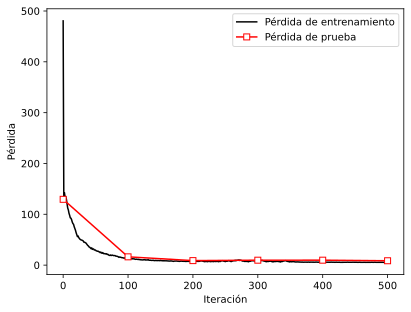

In [96]:
# Graficar las pérdidas
plt.plot(train_loss, 'k', label='Pérdida de entrenamiento')
plt.plot(
    range(0, num_samples, 100),
    test_loss[::100],
    'rs-',
    markerfacecolor='w',
    markersize=6,
    label='Pérdida de prueba',
)

plt.legend()
plt.gca().set(xlabel='Iteración', ylabel='Pérdida')
plt.show()

In [97]:
# Generar texto nuevo
startToks = torch.tensor(
    tokenizer.encode('The man-mountain shall not depart from our dominions')
).unsqueeze(0)

# Generación de texto
Y = model.generate(startToks.to(device), max_new_tokens=100)
print(tokenizer.decode(Y[0].tolist()).replace('\r', '\n'))

The man-mountain shall not depart from our dominions courtness of one the limited because it, food in every them are

 afraid, that reason to be he governor on the emperor spoke than a veryupon

and white, without so any business. But Japaneseheld suffer hisowersous from a liquid. I R

He was as many mar ofof his thousand

CHAPTER traitor did;feet of surprised from theon notes; cr pleased to virtue milesumst himself, partial my preservation seven me I was so great




In [98]:
# El modelo con pocos datos sigue aprendiendo caracteristicas importantes del texto

### Dinámica de Muestreo y Aprendizaje Rápido en LLMs

#### 1. Muestreo Aleatorio (*Random Sampling*) frente a Cobertura Total
* **Compromiso del método:** Extraer lotes al azar simplifica enormemente el código de ingestión y aligera el bucle de entrenamiento, aunque introduce el riesgo teórico de sobre-muestrear ciertas secuencias y omitir otras.
* **Datos limitados vs. Corpus masivo:**
  * En dominios con datos escasos o críticos (como visión computacional en imágenes médicas), omitir ejemplos no es viable: cada muestra cuenta y se exige iterar sobre el 100% del conjunto de datos.
  * En el modelado de lenguaje natural, la abundancia extrema de texto público reduce significativamente este riesgo. La enorme variabilidad estadística hace que las pérdidas por muestreo aleatorio sean marginales frente a la ventaja de un flujo continuo y diverso de tokens.

---

#### 2. Adquisición Temprana de la Sintaxis y Estructura
A pesar de entrenarse con una cantidad muy limitada de datos y apenas unos cientos de pasos de optimización, el modelo muestra una convergencia estructural notable:
* **Más allá de tokens al azar:** Deja de predecir secuencias puramente caóticas y comienza a emitir palabras coherentes con el contexto del corpus.
* **Alineación con la forma del lenguaje:** Captura con rapidez elementos ortotipográficos y de formato:
  * Espaciados correctos entre términos.
  * Saltos de línea y distribución de párrafos.
  * Signos de puntuación elementales.
* **Conclusión:** Aunque la coherencia semántica a largo plazo aún no está consolidada, la red demuestra que las regularidades sintácticas y la morfología superficial del texto son los primeros patrones que un modelo de lenguaje asimila, incluso bajo restricciones severas de datos y cómputo.